# Exercise: CNN for MNIST digit classification

In this exercise, we build a small convolutional neural network for classifying all **10 digits** in the MNIST dataset.

The network should have:

- **one convolutional layer** with **10 learned features**
- **average pooling over the spatial dimensions**
- **two dense layers** for classification

After training, we will:
- evaluate the model on the test set,
- visualize the **confusion matrix**,
- visualize the **10 learned convolutional features**.

## Learning goals

After this exercise, you should be able to:

- prepare MNIST data for a CNN in PyTorch,
- define a small convolutional neural network,
- train it for multiclass classification,
- evaluate predictions using a confusion matrix,
- inspect learned convolutional filters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Load and preprocess the data

We load the MNIST dataset, normalize the pixel values to the range $[0,1]$, and convert the arrays to PyTorch tensors.

Datatype and max value:  uint8 255
Shape of normalized training images: (60000, 28, 28)
Shape of normalized test images: (10000, 28, 28)


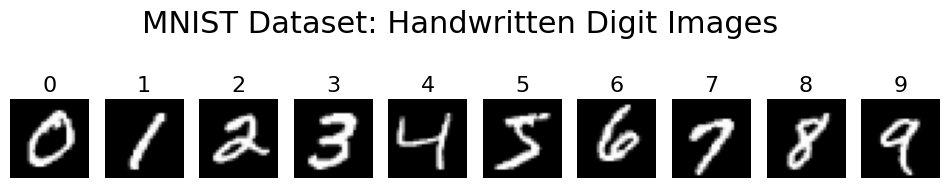

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# total size
n_train = x_train.shape[0]
n_test = x_test.shape[0]
n_total = n_train + n_test

# ------------------------------------------------------------
# pick one example of each digit
# ------------------------------------------------------------
examples = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    examples.append(x_train[idx])

# ------------------------------------------------------------
# create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

gs = fig.add_gridspec(2, 10, height_ratios=[1,1.2])

# title
fig.suptitle("MNIST Dataset: Handwritten Digit Images", fontsize=22)

# ------------------------------------------------------------
# row of example digits
# ------------------------------------------------------------
for i in range(10):

    ax = fig.add_subplot(gs[0,i])

    ax.imshow(examples[i], cmap="gray")
    ax.set_title(str(i), fontsize=16)
    ax.axis("off")

print("Datatype and max value: ",x_train.dtype, np.max(x_train))
# Normalize image data (0-255 to 0.0-1.0)
x_train_norm = x_train.astype(np.float32) / 255.0
y_train_orig = y_train
x_test_norm = x_test.astype(np.float32) / 255.0
y_test_orig = y_test

y_train_orig=torch.from_numpy(y_train_orig)
y_test_orig=torch.from_numpy(y_test_orig)


print(f'Shape of normalized training images: {x_train_norm.shape}')
print(f'Shape of normalized test images: {x_test_norm.shape}')

## Define the CNN

The model uses:
1. It receives inputs of size B x C x W x H (B: batchsize; C: number of channels; W and H are width and height). Note that MNIST images are grayscale images that have just one channel, i.e., **C=1**
2. inputs are passed through one convolutional layer with **10 filters** and a kernel size of 21
3. then, a ReLU activation,
4. Then spatial averaging is performed *B x C x W x H* sized tensors are averaged over the last two dimensions
5. the *BxC* features are passed through a dense layer followed by ReLU activation
6. the output layer is dense and has output dimension 10 (to classify the 10 digits). It deploys a softmax activation funciton to output probabilities.

In [3]:
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, num_filters=10, hidden_size=64, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=num_filters, kernel_size=21)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(num_filters, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x=self.conv1(x)
        x=self.relu(x)
        x=torch.mean(x,dim=(2,3))

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = F.softmax(x, dim=1) # Apply softmax across the class dimension
        return x


## Training the model

- use one-hot-encoding, i.e., target outputs are of the size B x 10
- use cross-entropy loss for multiclass classification,
- the Adam optimizer with learning rate 0.01
- 2000 training steps with a batch size B = 32

Hint: For taking a random batch of size batch_size from input X and output Y you can use:

idx = torch.randperm(X.size(0))[:batch_size]

X_batch = X[idx]

Y_batch = Y[idx]

In [4]:
import torch.optim as optim



# Instantiate the model (already done in previous cell)

model = SmallCNN()
print(model)

# preparing the training data
## X is turned into a torch tensor and transformed from format B x H x W to format Bx Cx Hx W
X=torch.from_numpy(x_train_norm)
X=X.unsqueeze(1)
##  output is one-hot-encoded
Y=torch.stack([(y_train_orig==i).float() for i in range(0,10)],axis=1)


# preparing the test data
X_test=torch.from_numpy(x_test_norm)
X_test=X_test.unsqueeze(1)
Y_test=torch.stack([(y_test_orig==i).float() for i in range(0,10)],axis=1)

# Define loss function and optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of steps for training
num_steps = 2000
batch_size=32
# Training loop
for step in range(num_steps):

    idx = torch.randperm(X.size(0))[:batch_size]
    X_batch = X[idx]
    Y_batch = Y[idx]
    # Forward pass
    outputs = model(X_batch.float())
    loss = -(Y_batch.float() * torch.log(outputs+1e-10)).sum(dim=1).mean()


    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (step+1) % 100 == 0:
      print(f'Epoch [{step+1}/{num_steps}], Loss: {loss.item():.4f}')

print('Training finished.')

SmallCNN(
  (conv1): Conv2d(1, 10, kernel_size=(21, 21), stride=(1, 1))
  (relu): ReLU()
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [100/2000], Loss: 0.7433
Epoch [200/2000], Loss: 0.8365
Epoch [300/2000], Loss: 0.6829
Epoch [400/2000], Loss: 0.6157
Epoch [500/2000], Loss: 0.0893
Epoch [600/2000], Loss: 0.4300
Epoch [700/2000], Loss: 0.2424
Epoch [800/2000], Loss: 0.3666
Epoch [900/2000], Loss: 0.0805
Epoch [1000/2000], Loss: 0.2306
Epoch [1100/2000], Loss: 0.3641
Epoch [1200/2000], Loss: 0.3524
Epoch [1300/2000], Loss: 0.5629
Epoch [1400/2000], Loss: 0.1177
Epoch [1500/2000], Loss: 0.1682
Epoch [1600/2000], Loss: 0.1916
Epoch [1700/2000], Loss: 0.1667
Epoch [1800/2000], Loss: 0.1162
Epoch [1900/2000], Loss: 0.3047
Epoch [2000/2000], Loss: 0.0770
Training finished.


## Evaluate the model

We compute the accuracy on  the train and on the test data

In [5]:
model.eval()


Y_pred=model(X)
_, predicted_labels = torch.max(Y_pred, 1)
_, true_labels = torch.max(Y, 1)
accuracy=torch.mean((predicted_labels==true_labels).float())
accuracy_test=accuracy.item()*100
print(f'Accuracy of the model on the train data: {accuracy:.2f}%')


Y_test_pred=model(X_test)
_, predicted_labels = torch.max(Y_test_pred, 1)
_, true_labels = torch.max(Y_test, 1)
accuracy=torch.mean((predicted_labels==true_labels).float())
accuracy_test=accuracy.item()*100
print(f'Accuracy of the model on the test data: {accuracy:.2f}%')

Accuracy of the model on the train data: 0.93%
Accuracy of the model on the test data: 0.93%


## Visualize the confusion matrix

We visualize the confusion matrix

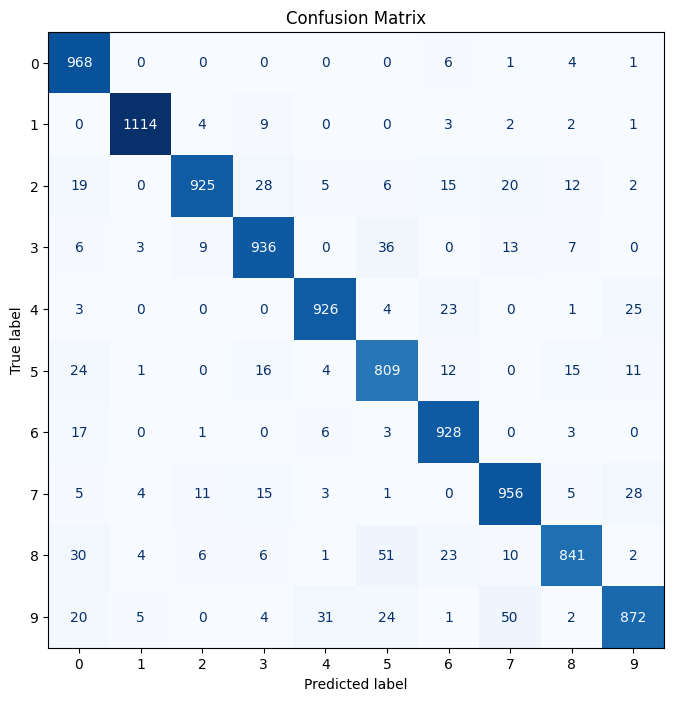

In [6]:
cm = confusion_matrix(true_labels.numpy(), predicted_labels.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## Visualize the 20 learned convolutional features

We inspect the learned filters from the convolutional layer.
Each filter is shown as a small image.

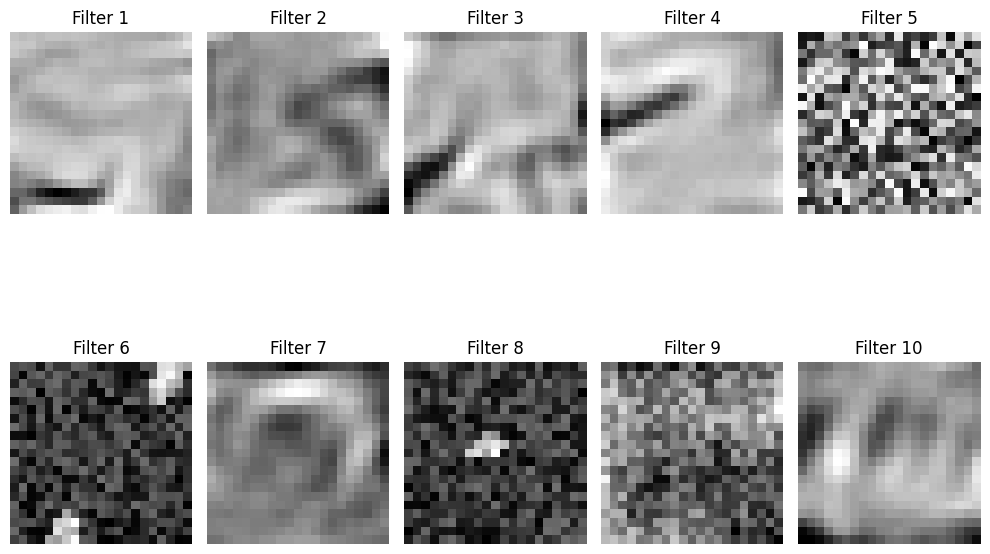

In [7]:
filters = model.conv1.weight.detach().cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()